In [9]:
import pandas as pd

import random
import geopandas as gpd
import numpy as np
import os

import sys

sys.path.insert(0, "../../Modules")

from utils import process_greek, create_grid

enc = 'utf-8'
dec = 'greek8'
random.seed(0)
np.random.seed(0)

In [10]:
import warnings
warnings.filterwarnings('ignore')

In [11]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_ID = 'EL61'
NUTS1_COLNAME = 'NUTS1_ID'
NUTS2_COLNAME = 'NUTS2_ID'

In [12]:
shapefile_gdf = gpd.read_file(f"../../Europe Shapefiles/Greece/data/EL_Whole.shp",  encoding=enc)

In [13]:
shapefile_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
0,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL301,Voreios Tomeas Athinon,Βόρειος Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.80300 37.98545..."
1,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL302,Dytikos Tomeas Athinon,Δυτικός Τομέας Αθηνών,4.0,1,1,"MULTIPOLYGON (((23.72005 38.06296, 23.72884 38..."
2,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL303,Kentrikos Tomeas Athinon,Κεντρικός Τομέας Αθηνών,4.0,1,2,"POLYGON ((23.82310 37.97392, 23.82185 37.97195..."
3,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL304,Notios Tomeas Athinon,Νότιος Τομέας Αθηνών,4.0,1,1,"POLYGON ((23.80679 37.91784, 23.80240 37.91205..."
4,EL,Greece,EL3,Attiki,Αττική,EL30,Attiki,Aττική,EL305,Anatoliki Attiki,Ανατολική Αττική,2.0,1,1,"MULTIPOLYGON (((24.10518 38.18205, 24.10171 38..."


In [14]:
print(f'shapefile\'s CRS before conversion: {shapefile_gdf.crs}')
shapefile_gdf = shapefile_gdf.to_crs(epsg=4326)
print(f'shapefile\'s CRS after conversion: {shapefile_gdf.crs}')

shapefile's CRS before conversion: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0],UNIT["Degree",0.0174532925199433],AXIS["Longitude",EAST],AXIS["Latitude",NORTH]]
shapefile's CRS after conversion: EPSG:4326


In [15]:
shapefile_gdf[NUTS2_COLNAME].unique()

array(['EL30', 'EL41', 'EL42', 'EL43', 'EL51', 'EL52', 'EL53', 'EL54',
       'EL61', 'EL62', 'EL63', 'EL64', 'EL65'], dtype=object)

In [16]:
nuts3_gdf = shapefile_gdf.loc[shapefile_gdf[NUTS2_COLNAME] == f'{NUTS2_ID}'].copy()
nuts3_gdf.head()

,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE,geometry
34,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL61,Thessalia,Θεσσαλία,EL611,"Karditsa, Trikala","Καρδίτσα, Τρίκαλα",2.0,3,3,"POLYGON ((21.91769 39.85205, 21.95557 39.84969..."
35,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL61,Thessalia,Θεσσαλία,EL612,Larisa,Λάρισα,2.0,2,1,"POLYGON ((22.66458 39.97476, 22.70870 39.95235..."
36,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL61,Thessalia,Θεσσαλία,EL613,"Magnisia, Sporades","Μαγνησία, Σποράδες",2.0,2,1,"MULTIPOLYGON (((24.32680 39.33398, 24.32475 39..."


<Axes: >

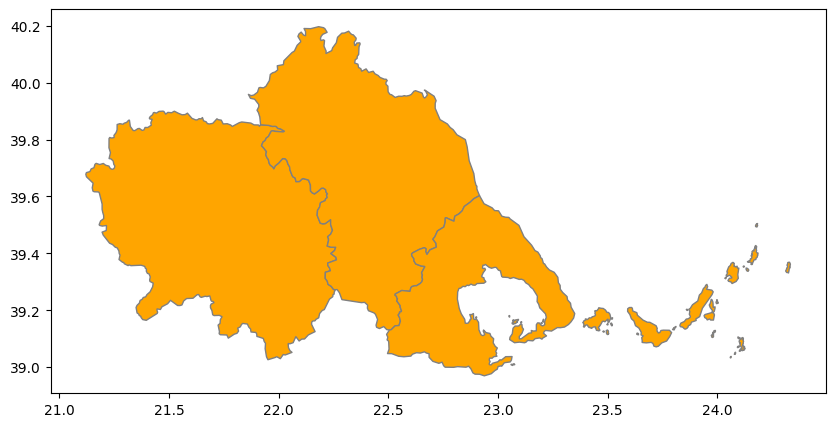

In [17]:
nuts3_gdf.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [18]:
nuts2_gdf = nuts3_gdf.dissolve(by = NUTS1_COLNAME, as_index = False)

<Axes: >

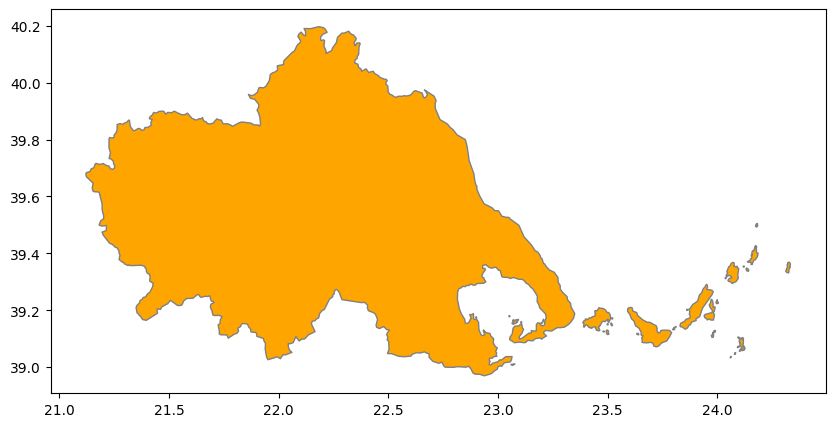

In [19]:
nuts2_gdf.plot(facecolor="none", edgecolor='grey', figsize=(10, 10), color='orange')

In [20]:
nuts2_gdf = nuts2_gdf[['NUTS2_ID', 'NUTS2_NAME', 'geometry']]
nuts2_gdf.reset_index(inplace=True, drop = True)

In [21]:
empty_gdf = gpd.GeoDataFrame(columns=['geometry'], geometry='geometry', crs='EPSG:4326')

df_grid = create_grid(empty_gdf, nuts2_gdf, col_municipal=NUTS2_COLNAME, dimension=2)
# df_grid_2.to_csv('data/grid_2.csv', index=False)
# # df_grid_2 = pd.read_csv('data/grid_2.csv')
# # df_grid_2['geometry'] = gpd.GeoSeries.from_wkt(df_grid_2['geometry'])
# # df_grid_2 = gpd.GeoDataFrame(df_grid_2, geometry='geometry')

In [22]:
df_grid.shape

(3238, 5)

In [23]:
df_grid.head()

,geometry,centers,NUTS2_ID,x,y
0,"POLYGON ((21.16704 39.67045, 21.16704 39.68842...",POINT (21.155488402451258 39.67943231820849),EL61,21.15549,39.67943
1,"POLYGON ((21.19015 39.61655, 21.19015 39.63452...",POINT (21.178597337418765 39.625532243407854),EL61,21.17860,39.62553
2,"POLYGON ((21.19015 39.63452, 21.19015 39.65248...",POINT (21.178597337418765 39.643498935008054),EL61,21.17860,39.64350
3,"POLYGON ((21.19015 39.65248, 21.19015 39.67045...",POINT (21.178597337418765 39.661465626608276),EL61,21.17860,39.66147
4,"POLYGON ((21.19015 39.67045, 21.19015 39.68842...",POINT (21.178597337418765 39.67943231820849),EL61,21.17860,39.67943


<Axes: >

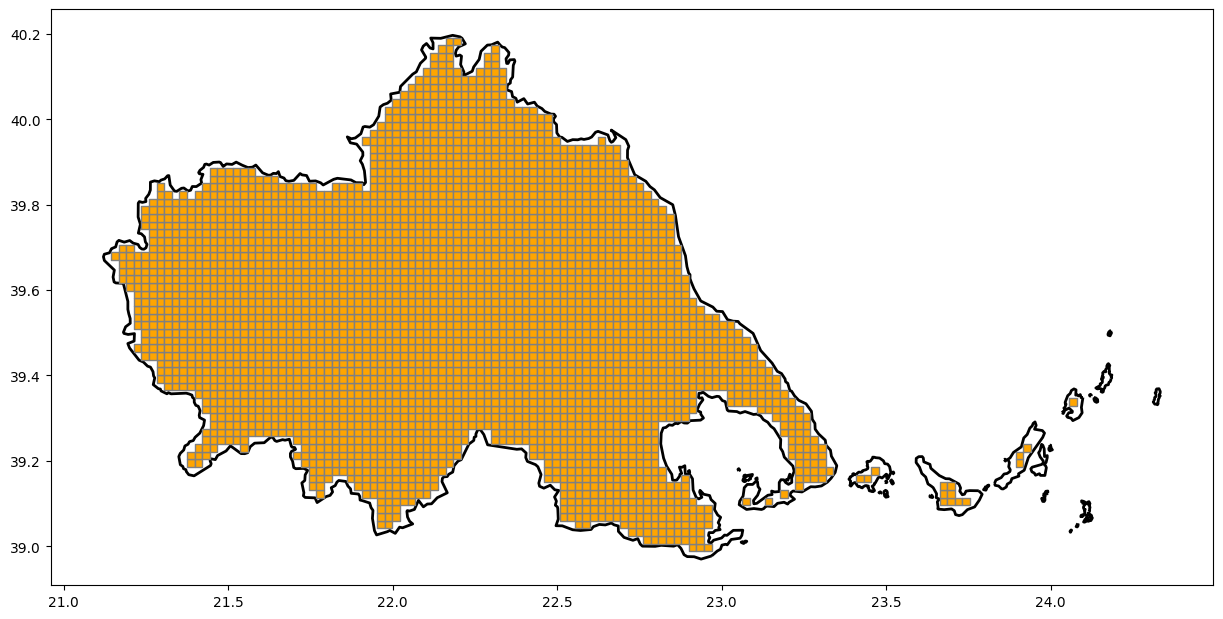

In [24]:
ax = nuts2_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
df_grid.plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [25]:
df_grid.set_geometry('centers', inplace=True)

In [26]:
gdf_merged = gpd.sjoin(df_grid, nuts3_gdf, how='left', op='within')
gdf_merged.set_geometry('geometry', inplace=True)

<Axes: >

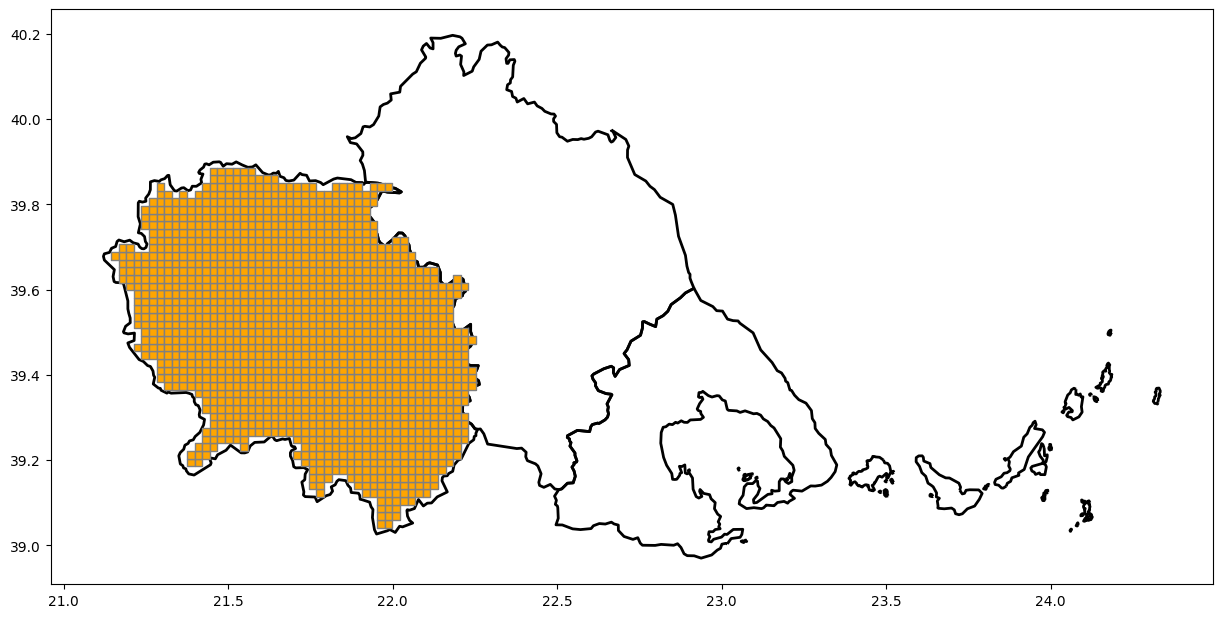

In [27]:
ax = nuts3_gdf.plot(figsize=(15, 15), facecolor="none", edgecolor='black', lw=2)
gdf_merged[gdf_merged['NUTS3_ID'] == 'EL611'].plot(facecolor="none", edgecolor='grey', ax=ax, color='orange')

In [28]:
gdf_merged.head()

,geometry,centers,NUTS2_ID_left,x,y,index_right,CNTR_CODE,CNTR_NAME,NUTS1_ID,NUTS1_LATN,NUTS1_NAME,NUTS2_ID_right,NUTS2_LATN,NUTS2_NAME,NUTS3_ID,NUTS3_LATN,NUTS3_NAME,MOUNT_TYPE,URBN_TYPE,COAST_TYPE
0,"POLYGON ((21.16704 39.67045, 21.16704 39.68842...",POINT (21.15549 39.67943),EL61,21.15549,39.67943,34,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL61,Thessalia,Θεσσαλία,EL611,"Karditsa, Trikala","Καρδίτσα, Τρίκαλα",2.0,3,3
1,"POLYGON ((21.19015 39.61655, 21.19015 39.63452...",POINT (21.17860 39.62553),EL61,21.17860,39.62553,34,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL61,Thessalia,Θεσσαλία,EL611,"Karditsa, Trikala","Καρδίτσα, Τρίκαλα",2.0,3,3
2,"POLYGON ((21.19015 39.63452, 21.19015 39.65248...",POINT (21.17860 39.64350),EL61,21.17860,39.64350,34,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL61,Thessalia,Θεσσαλία,EL611,"Karditsa, Trikala","Καρδίτσα, Τρίκαλα",2.0,3,3
3,"POLYGON ((21.19015 39.65248, 21.19015 39.67045...",POINT (21.17860 39.66147),EL61,21.17860,39.66147,34,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL61,Thessalia,Θεσσαλία,EL611,"Karditsa, Trikala","Καρδίτσα, Τρίκαλα",2.0,3,3
4,"POLYGON ((21.19015 39.67045, 21.19015 39.68842...",POINT (21.17860 39.67943),EL61,21.17860,39.67943,34,EL,Greece,EL6,Kentriki Elláda,Κεντρική Ελλάδα,EL61,Thessalia,Θεσσαλία,EL611,"Karditsa, Trikala","Καρδίτσα, Τρίκαλα",2.0,3,3


In [29]:
final_grid = gdf_merged[['NUTS2_ID_left', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y', 'geometry']]
final_grid.set_geometry('geometry', inplace=True)
final_grid.rename(columns={'NUTS2_ID_left': "NUTS2_ID"}, inplace=True)
final_grid.sort_values(by=['NUTS3_ID', 'x', 'y'], inplace = True)
final_grid.reset_index(drop=True, inplace=True)

In [30]:
final_grid['cell_code'] = final_grid['NUTS3_ID'] + pd.Series(final_grid.index + 1).apply(lambda x: f"{x:06d}")
process_greek(final_grid, 'NUTS3_NAME')
process_greek(final_grid, 'NUTS2_NAME')

In [31]:
final_grid = final_grid[['NUTS2_ID', 'NUTS2_NAME', 'NUTS3_ID', 'NUTS3_NAME', 'x', 'y', 'cell_code', 'geometry']]

In [32]:
final_grid.head()

,NUTS2_ID,NUTS2_NAME,NUTS3_ID,NUTS3_NAME,x,y,cell_code,geometry
0,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.15549,39.67943,EL611000001,"POLYGON ((21.16704 39.67045, 21.16704 39.68842..."
1,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.17860,39.62553,EL611000002,"POLYGON ((21.19015 39.61655, 21.19015 39.63452..."
2,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.17860,39.64350,EL611000003,"POLYGON ((21.19015 39.63452, 21.19015 39.65248..."
3,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.17860,39.66147,EL611000004,"POLYGON ((21.19015 39.65248, 21.19015 39.67045..."
4,EL61,θεσσαλια,EL611,"καρδιτσα, τρικαλα",21.17860,39.67943,EL611000005,"POLYGON ((21.19015 39.67045, 21.19015 39.68842..."


In [33]:
final_grid.drop(columns='geometry').to_csv(f'../data/GR_{NUTS2}_Grid.csv', encoding=enc, index = False)
final_grid.to_file(f'../data/GR_{NUTS2}_Grid.shp', encoding = 'utf-8')